In [1]:
# generic imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# respymethods imports
import respymethods.Simulation as rmsim
import respymethods.RespStats as rmstats

In [2]:
# create dictionary for simulation parameters
# Note that for higher dimensional simulations this can be streamlined through Simulation.create_dict_from_toml 
sim_cfg = {'n_subjects': 20, 
           'n_phase_bins': 51, 
           'n_trials': 500, 
           'n_perms': 1000, 
           'effect_mag': 0.1, 
           'trl_noise': -2, 
           'intersubj_noise': -1.2, 
           'range_bin': 0.1, 
          }

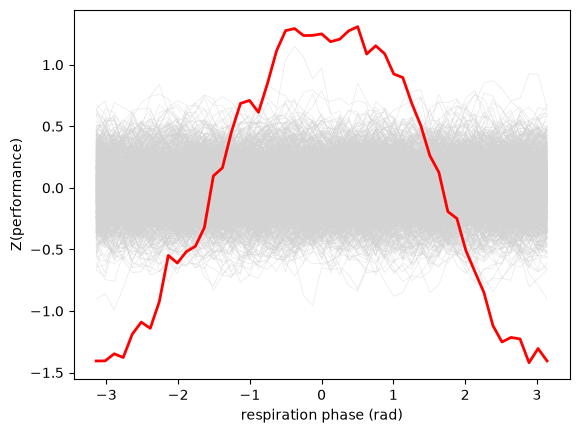

In [3]:
# create the simulated data given the parameter space and plot
smpl, perms, theta = rmsim.create_sample(**sim_cfg)                
aggr_dat = np.concatenate((perms, smpl[:, :, np.newaxis]),
                          axis=2)
z_along_permutations = zscore(aggr_dat, axis=2)
avg_subjects = z_along_permutations.mean(axis=1)

# Plot surrogate data (light grey)
plt.plot(theta, avg_subjects[:, :-1], color='lightgrey', linewidth=0.5, alpha=0.5)
# Plot test data (red)
plt.plot(theta, avg_subjects[:, -1], color='red', linewidth=2)
plt.xlabel("respiration phase (rad)")
plt.ylabel("Z(performance)")
plt.show()

In [4]:
# compute t statistics
permemp = (np.sqrt(sim_cfg["n_subjects"])*
           z_along_permutations.mean(axis=1)/z_along_permutations.std(axis=1)) 

# select emprical and permuted data, and run circular permutation on it
emp = permemp[:, -1]
perm = permemp[:, :-1]
[bounds, summary] = rmstats.circ_perm(emp, perm, theta, alternative="two_sided")

print(summary)

{'idxs': [[0, 1, 2, 3, 4, 5, 6, 7, 43, 44, 45, 46, 47, 48, 49, 50], [16, 17], [19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]], 'clustmass_stat': [np.float64(-82.73047407410985), np.float64(4.727593923516352), np.float64(66.01909081697707)], 'p_ecdf': [np.float64(0.000998003992015968), np.float64(0.811377245508982), np.float64(0.999001996007984)], 'p': [np.float64(0.000998003992015968), np.float64(0.37524950099800397), np.float64(0.000998003992015968)]}


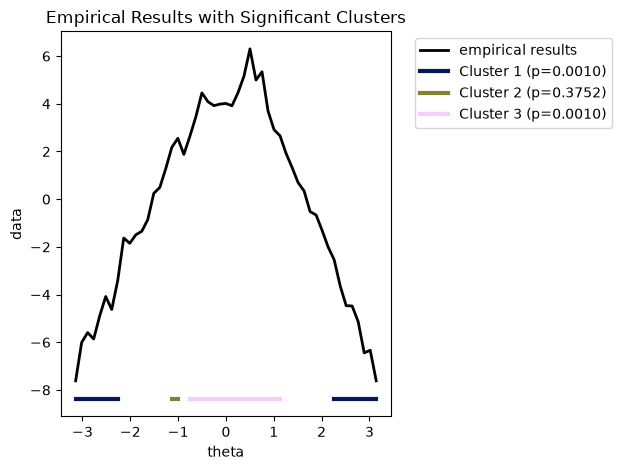

In [5]:
from respymethods.Helpers import plot_clusters

plot_clusters(summary, theta, emp)